In [1]:
# %reset
import numpy as np
import sys,os
import readgadget
import MAS_library as MASL
import pickle as pk
import readfof
import matplotlib
import h5py as h5
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
pl.rc('font', family='DejaVu Sans')
%matplotlib inline



%load_ext Cython

    
    



In [2]:
%load_ext Cython



The Cython extension is already loaded. To reload it, use:
  %reload_ext Cython


In [3]:
%%cython

cimport numpy as np
cpdef void NGP_mass(np.float32_t[:,:] pos, np.float32_t[:] logM, np.float32_t[:,:,:,:] gridM, float BoxSize):

    cdef int axis,dims,coord,nMmax,jM
    cdef long i,particles
    cdef float inv_cell_size
    cdef int index[3]

    # find number of particles, the inverse of the cell size and dims
    particles = pos.shape[0];  coord = pos.shape[1];  dims = gridM.shape[0]; nMmax = gridM.shape[3]
    inv_cell_size = dims/BoxSize

    # when computing things in 2D, use the index[2]=0 plane
    for i in range(3):  index[i] = 0

    # do a loop over all particles
    for i in range(particles):
        for axis in range(coord):
            index[axis] = <int>(pos[i,axis]*inv_cell_size + 0.5)
            index[axis] = (index[axis]+dims)%dims
        for jM in range(nMmax):
            if gridM[index[0],index[1],index[2], jM] == 0:
                gridM[index[0],index[1],index[2], jM] = logM[i]
                break
            else:
                pass
        
        
        
        

In [4]:
%%cython
cimport numpy as np
cpdef void NGP_xyz(np.float32_t[:,:] pos, np.float32_t[:,:,:,:,:] gridM, float BoxSize):

    cdef int axis,dims,coord,nMmax,jM
    cdef long i,particles
    cdef float inv_cell_size
    cdef float pos0, pos1, pos2
    cdef int index[3]
    cdef int tobreak

    # find number of particles, the inverse of the cell size and dims
    particles = pos.shape[0];  coord = pos.shape[1];  dims = gridM.shape[0]; nMmax = gridM.shape[3]
    inv_cell_size = dims/BoxSize

    # when computing things in 2D, use the index[2]=0 plane
    for i in range(3):  index[i] = 0

    # do a loop over all particles
    for i in range(particles):
        for axis in range(coord):
            index[axis] = <int>(pos[i,axis]*inv_cell_size + 0.5)
            if axis == 0:
                pos0 = pos[i,axis] - index[axis]*BoxSize/dims
            if axis == 1:
                pos1 = pos[i,axis] - index[axis]*BoxSize/dims
            if axis == 2:
                pos2 = pos[i,axis] - index[axis]*BoxSize/dims
            index[axis] = (index[axis]+dims)%dims
        for jM in range(nMmax):
            if (gridM[index[0],index[1],index[2], jM, 0] == 0) and (gridM[index[0],index[1],index[2], jM, 1] == 0) and (gridM[index[0],index[1],index[2], jM, 2] == 0):
                gridM[index[0],index[1],index[2], jM, 0] = pos0
                gridM[index[0],index[1],index[2], jM, 1] = pos1
                gridM[index[0],index[1],index[2], jM, 2] = pos2
                # gridM[index[0],index[1],index[2], jM, 3] = logM[i]
                break
            else:
                pass


            

In [5]:

%%cython
cimport numpy as np
cpdef void NGP_xyzM(np.float32_t[:,:] pos, np.float32_t[:] logM, np.float32_t[:,:,:,:,:] gridM, float BoxSize):

    cdef int axis,dims,coord,nMmax,jM
    cdef long i,particles
    cdef float inv_cell_size
    cdef float pos0, pos1, pos2
    cdef int index[3]
    cdef int tobreak

    # find number of particles, the inverse of the cell size and dims
    particles = pos.shape[0];  coord = pos.shape[1];  dims = gridM.shape[0]; nMmax = gridM.shape[3]
    inv_cell_size = dims/BoxSize

    # when computing things in 2D, use the index[2]=0 plane
    for i in range(3):  index[i] = 0

    # do a loop over all particles
    for i in range(particles):
        for axis in range(coord):
            index[axis] = <int>(pos[i,axis]*inv_cell_size + 0.5)
            if axis == 0:
                pos0 = pos[i,axis] - index[axis]*BoxSize/dims
            if axis == 1:
                pos1 = pos[i,axis] - index[axis]*BoxSize/dims
            if axis == 2:
                pos2 = pos[i,axis] - index[axis]*BoxSize/dims
            index[axis] = (index[axis]+dims)%dims
        for jM in range(nMmax):
            if (gridM[index[0],index[1],index[2], jM, 0] == 0) and (gridM[index[0],index[1],index[2], jM, 1] == 0) and (gridM[index[0],index[1],index[2], jM, 2] == 0) and (gridM[index[0],index[1],index[2], jM, 3] == 0):
                gridM[index[0],index[1],index[2], jM, 0] = pos0
                gridM[index[0],index[1],index[2], jM, 1] = pos1
                gridM[index[0],index[1],index[2], jM, 2] = pos2
                gridM[index[0],index[1],index[2], jM, 3] = logM[i]
                break
            else:
                pass


            
            
            

In [6]:
%%cython
cimport numpy as np
cpdef void NGP_xyz_vxvyvz(np.float32_t[:,:] pos, np.float32_t[:, :] vel, np.float32_t[:,:,:,:,:] gridM, float BoxSize):

    cdef int axis,dims,coord,nMmax,jM
    cdef long i,particles
    cdef float inv_cell_size
    cdef float pos0, pos1, pos2
    cdef int index[3]
    cdef int tobreak

    # find number of particles, the inverse of the cell size and dims
    particles = pos.shape[0];  coord = pos.shape[1];  dims = gridM.shape[0]; nMmax = gridM.shape[3]
    inv_cell_size = dims/BoxSize

    # when computing things in 2D, use the index[2]=0 plane
    for i in range(3):  index[i] = 0

    # do a loop over all particles
    for i in range(particles):
        for axis in range(coord):
            index[axis] = <int>(pos[i,axis]*inv_cell_size + 0.5)
            if axis == 0:
                pos0 = pos[i,axis] - index[axis]*BoxSize/dims
                
            if axis == 1:
                pos1 = pos[i,axis] - index[axis]*BoxSize/dims
                
            if axis == 2:
                pos2 = pos[i,axis] - index[axis]*BoxSize/dims
                
            index[axis] = (index[axis]+dims)%dims
        for jM in range(nMmax):
            if (gridM[index[0],index[1],index[2], jM, 0] == 0) and (gridM[index[0],index[1],index[2], jM, 1] == 0) and (gridM[index[0],index[1],index[2], jM, 2] == 0) and (gridM[index[0],index[1],index[2], jM, 3] == 0) and (gridM[index[0],index[1],index[2], jM, 4] == 0) and (gridM[index[0],index[1],index[2], jM, 5] == 0):
                gridM[index[0],index[1],index[2], jM, 0] = pos0
                gridM[index[0],index[1],index[2], jM, 1] = pos1
                gridM[index[0],index[1],index[2], jM, 2] = pos2
                gridM[index[0],index[1],index[2], jM, 3] = vel[i,0]
                gridM[index[0],index[1],index[2], jM, 4] = vel[i,1]
                gridM[index[0],index[1],index[2], jM, 5] = vel[i,2]
                break
            else:
                pass


            
            
            

In [3]:
%%cython
cimport numpy as np
cpdef void NGP_xyz_prop(np.float32_t[:,:] pos, np.float32_t[:, :] prop, np.float32_t[:,:,:,:,:] gridM, float BoxSize):

    cdef int axis,dims,coord,nMmax,jM, coord_prop
    cdef long i,particles
    cdef float inv_cell_size
    cdef float pos0, pos1, pos2
    cdef int index[3]
    cdef int tobreak

    # find number of particles, the inverse of the cell size and dims
    particles = pos.shape[0];  coord = pos.shape[1];  dims = gridM.shape[0]; nMmax = gridM.shape[3]
    coord_prop = prop.shape[1]
    inv_cell_size = dims/BoxSize

    # when computing things in 2D, use the index[2]=0 plane
    for i in range(3):  index[i] = 0

    # do a loop over all particles
    for i in range(particles):
        for axis in range(coord):
            index[axis] = <int>(pos[i,axis]*inv_cell_size + 0.5)
            if axis == 0:
                pos0 = pos[i,axis] - index[axis]*BoxSize/dims
                
            if axis == 1:
                pos1 = pos[i,axis] - index[axis]*BoxSize/dims
                
            if axis == 2:
                pos2 = pos[i,axis] - index[axis]*BoxSize/dims
                
            index[axis] = (index[axis]+dims)%dims
        for jM in range(nMmax):
            if (gridM[index[0],index[1],index[2], jM, 0] == 0) and (gridM[index[0],index[1],index[2], jM, 1] == 0) and (gridM[index[0],index[1],index[2], jM, 2] == 0) and (gridM[index[0],index[1],index[2], jM, 3] == 0) and (gridM[index[0],index[1],index[2], jM, 4] == 0) and (gridM[index[0],index[1],index[2], jM, 5] == 0):
                gridM[index[0],index[1],index[2], jM, 0] = pos0
                gridM[index[0],index[1],index[2], jM, 1] = pos1
                gridM[index[0],index[1],index[2], jM, 2] = pos2
                for k in range(coord_prop):
                    gridM[index[0],index[1],index[2], jM, 3+k] = prop[i,k]
                break
            else:
                pass

            

In [8]:
isim_fid = 0



In [9]:
import numpy as np
import sys,os
import MAS_library as MASL
import pickle as pk
import h5py as h5
# from ngp_funcs import NGP_xyz_prop 
import skimage.measure as skmeasure

def mat_reshape(mat, grid1, grid2):
    '''
    Reshape input mat into (grid1, grid1, grid1, grid2, grid2, grid2) shape
    '''
    if len(mat.shape) == 3:
        mat_rs = np.reshape(mat, (grid1, grid2, grid1, grid2, grid1, grid2))
    else:
        mat_rs = np.reshape(mat, (grid1, grid2, grid1, grid2, grid1, grid2, *mat.shape[3:]))

    mat_rs = np.moveaxis(mat_rs, 1, 2)
    mat_rs = np.moveaxis(mat_rs, 4, 3)
    mat_rs = np.moveaxis(mat_rs, 3, 2)
    return mat_rs


def get_padded_mat(Npart, n_pad, grid_sbox, grid):
    Npart_pad = np.pad(Npart, n_pad, 'wrap')

    Npart_pad1 = np.zeros((grid, grid, grid, grid_sbox + 2*n_pad, grid_sbox + 2*n_pad, grid_sbox + 2*n_pad))
    fac = (grid_sbox + 2*n_pad)//grid_sbox    
    Npart_pad1_reduce = np.zeros((grid, grid, grid, grid_sbox, grid_sbox, grid_sbox))    
    xstart, ystart, zstart = n_pad, n_pad, n_pad
    for jx in range(grid):
        for jy in range(grid):
            for jz in range(grid):
                Npart_pad1[jx, jy, jz] = Npart_pad[xstart + jx * grid_sbox - n_pad:xstart + (jx + 1) * grid_sbox + n_pad,
                                                        ystart + jy * grid_sbox - n_pad:ystart + (jy + 1) * grid_sbox + n_pad,
                                                        zstart + jz * grid_sbox - n_pad:zstart + (jz + 1) * grid_sbox + n_pad]

                Npart_pad1_reduce[jx, jy, jz] = skmeasure.block_reduce(Npart_pad1[jx, jy, jz], (fac, fac, fac), np.mean)
    return Npart_pad1_reduce, Npart_pad1

nrand_sel_box = 128
norm_delta = 500
norm_vel = 500
BoxSize = 25.
grid = 8
# grid_sbox = 32
grid_sbox = 64
nvocab = 64
MAS_type = 'NGP'
grid_tot = grid_sbox * grid
# prop_min = np.array([7.5, 26, 26, 26, -0.75])
# prop_max = np.array([11.5, 30, 30, 30, 0.75])

prop_min = np.array([7.5, 26, 26, 26, -0.5])
prop_max = np.array([11.5, 30, 30, 30, 0.5])

Npoints_max_per_subvol = 25
nMax_points = 4
#sort by Mstar token:
ind_token_to_sort = 3
add_space_token = False

dim_pos = 3
dim_prop = 5
dim_tot = dim_pos + dim_prop

start_token = nvocab + 1
space_token = nvocab + 2
pad_token = nvocab + 3
end_token = nvocab + 4


sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH'
snapnum = 90
savefname_gals = f'{sdir}/gal_props/subhalo_proponly_snap_{snapnum}_grid_{grid_sbox}_isim_{isim_fid}_nrandsubsel_{nrand_sel_box}_nvocab{nvocab}_wSDSS_photometry_velx.pkl'


snap_dir_base = f'/work/hdd/bdne/spandey3/camels_tng/hydro/'
group_catalog = f'{snap_dir_base}/LH/LH_{isim_fid}/groups_0{snapnum}.hdf5'
photo_catalog = f'{snap_dir_base}/Photometry/IllustrisTNG/L25n256/LH/IllustrisTNG_LH_{isim_fid}_photometry.hdf5'
# open the catalogue
with h5.File(photo_catalog, "r") as hf:
    subhalo_index = np.array(hf[f"snap_0{snapnum}/SubhaloIndex"][:], dtype=int)
    g_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.g"][:])
    r_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.r"][:])
    i_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.i"][:])

# Read the stellar masses of the subhalos/galaxies
with h5.File(group_catalog, "r") as hf:
    M_star = np.log10(hf['Subhalo/SubhaloMassType'][:,4]*1e10 + 0.01) # Stellar masses in Msun/h
    pos = hf['Subhalo/SubhaloPos'][:]/1000.
    vel = hf['Subhalo/SubhaloVel'][:]/1000.

M_star = M_star[subhalo_index]
pos_h_truth = pos[subhalo_index]
vel_h_truth = vel[subhalo_index][:,0]
prop_truth_all = np.stack((M_star, g_band, r_band, i_band, vel_h_truth)).T

dim_pos = pos_h_truth.shape[1]
dim_prop = prop_truth_all.shape[1]


Nhalos_truth = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
MASL.NGP(np.float32(pos_h_truth), Nhalos_truth, BoxSize)
Nhalos_truth_rs = np.reshape(Nhalos_truth, (grid, grid_sbox, grid, grid_sbox, grid, grid_sbox))
Nhalos_truth_rs = mat_reshape(Nhalos_truth, grid, grid_sbox)


dfhalo_ngp_wxyz_props = np.float32(np.zeros((grid_tot, grid_tot, grid_tot, nMax_points, dim_pos + dim_prop)))
NGP_xyz_prop(np.float32(pos_h_truth), np.float32(prop_truth_all), dfhalo_ngp_wxyz_props, BoxSize)
dfhalo_ngp_wxyz_props_rs = mat_reshape(dfhalo_ngp_wxyz_props, grid, grid_sbox)


if add_space_token:
    max_sentence_length = 1 + Npoints_max_per_subvol*dim_tot + 1 + (Npoints_max_per_subvol - 1)
else:
    max_sentence_length = 1 + Npoints_max_per_subvol*dim_tot + 1

bins_digitize = np.linspace(-1e-3, 1, nvocab)
bins_digitize = np.insert(bins_digitize, 0, -1)

sentences_all = np.zeros((grid, grid, grid, max_sentence_length), dtype=np.int16)
for jx in range(grid):
    for jy in range(grid):
        for jz in range(grid):
            all_points_props_here = dfhalo_ngp_wxyz_props_rs[jx, jy, jz,...]
            Npoints_here = Nhalos_truth_rs[jx, jy, jz]
            indsel = np.where(Npoints_here > 0)
            Npoints_sel = Npoints_here[indsel]
            Npoints_sel_tot = np.sum(Npoints_sel)
            all_points_props_here_sel = all_points_props_here[indsel]
            word_array_all = []
            if len(Npoints_sel) > 0:    
                for jc1 in range(len(Npoints_sel)):
                    Npoints_jc = (Npoints_sel[jc1]).astype(np.int16)
                    for jc2 in range(Npoints_jc):
                        all_points_props_here_sel_per_point = (all_points_props_here_sel[jc1, jc2, :])
                        position_token = np.array([indsel[0][jc1],indsel[1][jc1],indsel[2][jc1]], dtype=np.int16)
                        props_tokens = []
                        all_props = all_points_props_here_sel_per_point[3:]
                        for jp in range(len(all_props)):
                            prop_norm = np.clip((all_props[jp] - prop_min[jp]) / (prop_max[jp] - prop_min[jp]), 0.001, 0.999)
                            prop_token = np.digitize(prop_norm, bins_digitize).astype(np.int16)
                            if prop_token == 0:
                                print(jp, prop_norm, prop_token)
                            props_tokens.append(prop_token)
                        props_token = np.array(props_tokens, dtype=np.int16)
                        all_tokens = np.concatenate((position_token, props_tokens))
                        word_array_all.append(all_tokens)
                word_array_all = np.array(word_array_all, dtype=np.int16)
                tosort_token_all = word_array_all[:, ind_token_to_sort]
                sort_inds = np.flip(np.argsort(tosort_token_all))
                word_array_all = word_array_all[sort_inds]
                if Npoints_sel_tot > Npoints_max_per_subvol:
                    word_array_all = word_array_all[:Npoints_max_per_subvol]        
                if add_space_token:
                    space_array = (np.array(np.zeros(word_array_all.shape[0]) + space_token, dtype=np.int16))[:,None]
                    word_array_all_concat = np.concatenate((word_array_all, space_array), axis=1)
                    sentence_here = np.concatenate(([start_token],(word_array_all_concat).flatten()[:-1], [end_token]))
                else:
                    sentence_here = np.concatenate(([start_token],(word_array_all).flatten(), [end_token]))
            else:
                sentence_here = np.array([start_token, end_token], dtype=np.int16)

            npad = Npoints_max_per_subvol - len(word_array_all)
            if npad > 0:
                pad_mat = np.array(np.zeros((npad, dim_tot)) + pad_token, dtype=np.int16)
                sentence_pad = pad_mat.flatten()
                sentence_here = np.concatenate((sentence_here, sentence_pad))
            sentences_all[jx, jy, jz] = sentence_here

story_full = sentences_all.reshape((grid**3, max_sentence_length))



In [10]:
saved = {'story_full': story_full, 'prop_truth_all': prop_truth_all, 'pos_h_truth': pos_h_truth, 'vel_h_truth': vel_h_truth, 'Nhalos_truth_rs': Nhalos_truth_rs}
with open('test_newcode.pk', 'wb') as f:
    pk.dump(saved, f)


In [10]:
snapnums = [90, 84, 78, 70, 60]
for js, snapnum in enumerate(snapnums):
    root = '/work/hdd/bdne/spandey3/camels_tng/DMO/LH'
    snap_fname =  f'{root}/LH_{isim_fid}/snapshot_0{snapnum}.hdf5'

    np.random.seed(0)
    df = h5.File(snap_fname, 'r')                
    pos_m_truth = df['PartType1']['Coordinates'][()]/1000.
    vel_m_truth = df['PartType1']['Velocities'][()]
    ids_m_truth = np.arange(len(pos_m_truth))

    rho_bar = len(pos_m_truth)/(BoxSize**3)
    vol_vox = (BoxSize/grid_tot)**3
    N_bar_vox = rho_bar * vol_vox

    Npart = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
    MASL.MA(np.float32(pos_m_truth), Npart, BoxSize, MAS_type, verbose=False)

    Npart /= N_bar_vox
    Npart /= norm_delta

    Npart_rs = mat_reshape(Npart, grid, grid_sbox)

    npad1 = grid_sbox
    Npart_pad1_rs, _ = get_padded_mat(Npart, int(npad1), grid_sbox, grid)

    npad2 = 2*grid_sbox
    Npart_pad2_rs, _ = get_padded_mat(Npart, int(npad2), grid_sbox, grid)

    vel_m_part = np.float32(np.zeros((grid_tot, grid_tot, grid_tot, 3)))

    Npart_cic = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
    MASL.MA(np.float32(pos_m_truth), Npart_cic, BoxSize, 'CIC', verbose=False)
    for jc in range(3):
        mom_jc = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
        MASL.MA(np.float32(pos_m_truth), mom_jc, BoxSize, 'CIC', verbose=False, W=vel_m_truth[:,jc].astype(np.float32))
        vel_m_jc = mom_jc/Npart_cic
        vel_m_jc[~np.isfinite(vel_m_jc)] = 0.0
        vel_m_part[..., jc] = vel_m_jc/norm_vel

    vel_m_part_rs = mat_reshape(vel_m_part, grid, grid_sbox)

    dmo_fields_all_snap = np.concat((Npart_rs[...,None], Npart_pad1_rs[...,None], Npart_pad2_rs[...,None], vel_m_part_rs), axis=-1)

    if js == 0:
        dmo_fields_all = dmo_fields_all_snap
    else:
        dmo_fields_all = np.concatenate((dmo_fields_all, dmo_fields_all_snap), axis=-1)

dmo_fields_all_rs = dmo_fields_all.reshape((grid**3, *dmo_fields_all.shape[3:]))





/tmp/ipykernel_2041190/559259560.py:37: RuntimeWarning: invalid value encountered in divide
  vel_m_jc = mom_jc/Npart_cic


/tmp/ipykernel_2041190/1230451712.py:4: RuntimeWarning: divide by zero encountered in log
  pl.imshow(np.log(np.sum(dmo_fields_all_rs[indp, :, :, :, 0], axis=-1)))


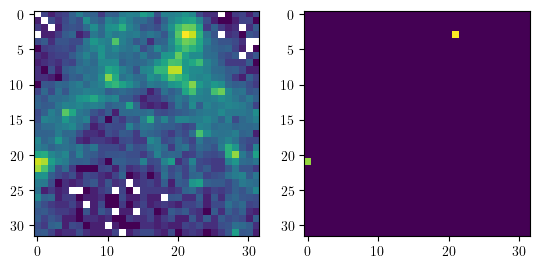

In [45]:
indp = 212
pl.figure()
pl.subplot(121)
pl.imshow(np.log(np.sum(dmo_fields_all_rs[indp, :, :, :, 0], axis=-1)))

pl.subplot(122)
dfhalo_ngp_wxyz_props_rs2 = dfhalo_ngp_wxyz_props_rs.reshape((grid**3, *dfhalo_ngp_wxyz_props_rs.shape[3:]))
pl.imshow((np.sum(dfhalo_ngp_wxyz_props_rs2[indp, :, :, :, 0, 3], axis=-1)))


In [ ]:
# Go from sentence to the original simulation:
sentences_all = story_full.reshape((grid, grid, grid, max_sentence_length))
for jx in range(grid):
    for jy in range(grid):
        for jz in range(grid):
            sentence_here = sentences_all[jx, jy, jz]
            ntokens_per_halo = 
            


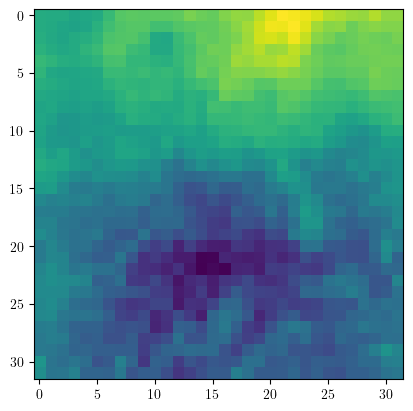

In [53]:
pl.figure()
pl.imshow((np.sum(vel_m_part_rs[0,5,2, :, :, :, 0], axis=-1)))



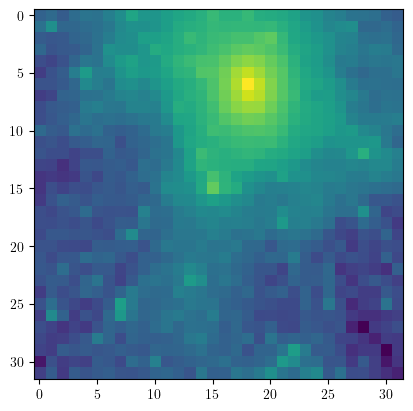

In [47]:
pl.figure()
pl.imshow(np.log(np.sum(Npart_rs[0,5,2, :, :, :], axis=-1)))


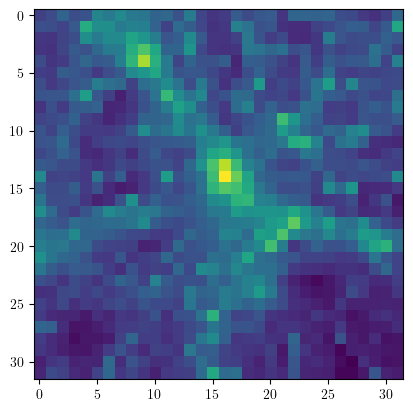

In [180]:
pl.figure()
pl.imshow(np.log(np.sum(Npart_pad1_rs_reduce[0,5,2, :, :, :], axis=-1)))



(32, 32, 32)

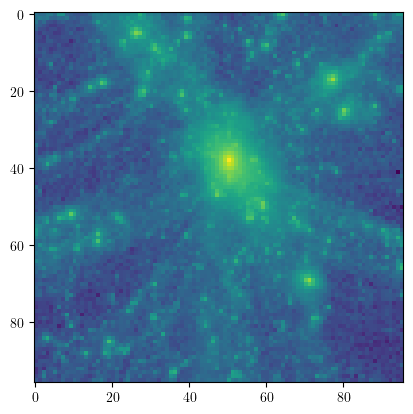

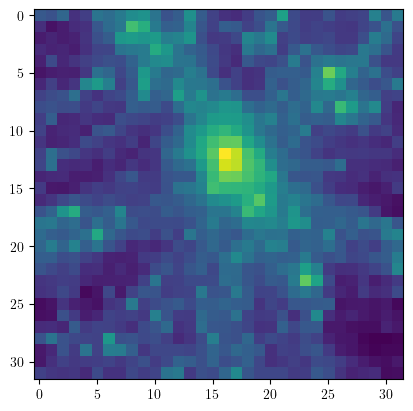

In [172]:
# Npart_pad1.shape, Npart_pad2.shape
# Npart_pad1_rs.shape
pl.figure()
pl.imshow(np.log(np.sum(skimage.measure.block_reduce(Npart_pad1_rs[0,5,2], 3, np.mean), axis=-1)))


/tmp/ipykernel_2088404/2296387468.py:4: RuntimeWarning: divide by zero encountered in log
  pl.imshow(np.log(np.sum(Npart_rs[0,5,3,:,:,:], axis=-1)))


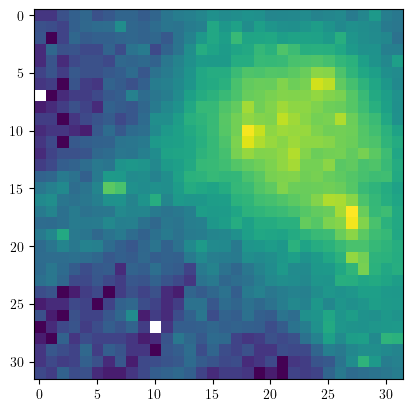

In [66]:
# dfhalo_ngp_wxyz_props_rs[0,5,3,:,:,:,:,0].shape
# np.amin(np.sum(np.sum(dfhalo_ngp_wxyz_props_rs[0,5,3,:,:,:,:,3], axis=-1), axis=-1))
pl.figure()
pl.imshow(np.log(np.sum(Npart_rs[0,5,3,:,:,:], axis=-1)))
# pl.imshow(np.log(np.sum(Npart_rs[0,5,2,:,:,:], axis=-1)))


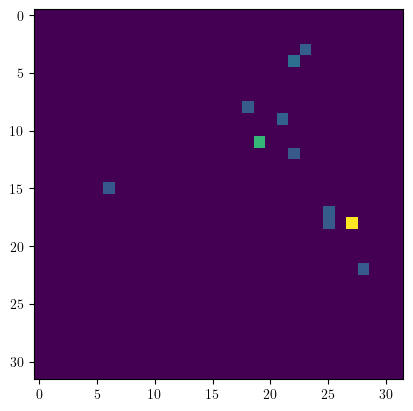

In [63]:
pl.figure()
pl.imshow(np.sum(np.sum(dfhalo_ngp_wxyz_props_rs[0,5,3,:,:,:,:,3], axis=-1), axis=-1))
# pl.imshow(np.sum(np.sum(dfhalo_ngp_wxyz_props_rs[0,5,2,:,:,:,:,3], axis=-1), axis=-1))



In [30]:
# dfhalo_ngp_wxyz_props_rs.shape
xall = (np.linspace(0, BoxSize/grid, grid_sbox + 1))
xarray = 0.5 * (xall[1:] + xall[:-1])
yarray = np.copy(xarray)
zarray = np.copy(xarray)
x_cy, y_cy, z_cy = np.meshgrid(xarray, yarray, zarray, indexing='ij')



In [32]:
# x_cy.shape



(32, 32, 32)

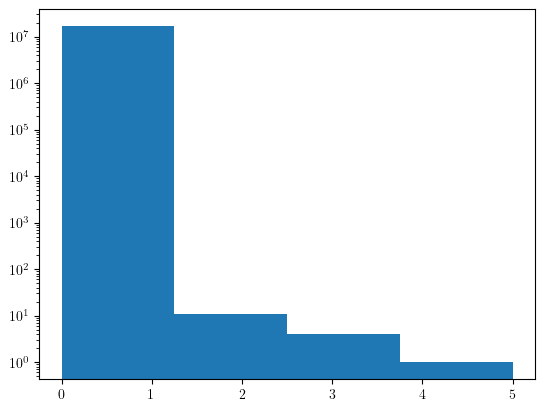

In [22]:
pl.figure()
_ = pl.hist(Nhalos_truth.flatten(), bins=4, range=(0,5))
pl.yscale('log')


In [4]:
import numpy as np
import sys,os
import MAS_library as MASL
import pickle as pk
import h5py as h5
# from ngp_funcs import NGP_xyz_prop 
import skimage.measure as skmeasure


def mat_reshape(mat, grid1, grid2):
    '''
    Reshape input mat into (grid1, grid1, grid1, grid2, grid2, grid2) shape
    '''
    if len(mat.shape) == 3:
        mat_rs = np.reshape(mat, (grid1, grid2, grid1, grid2, grid1, grid2))
    else:
        mat_rs = np.reshape(mat, (grid1, grid2, grid1, grid2, grid1, grid2, *mat.shape[3:]))

    mat_rs = np.moveaxis(mat_rs, 1, 2)
    mat_rs = np.moveaxis(mat_rs, 4, 3)
    mat_rs = np.moveaxis(mat_rs, 3, 2)
    return mat_rs


def get_padded_mat(Npart, n_pad, grid_sbox, grid):
    Npart_pad = np.pad(Npart, n_pad, 'wrap')

    Npart_pad1 = np.zeros((grid, grid, grid, grid_sbox + 2*n_pad, grid_sbox + 2*n_pad, grid_sbox + 2*n_pad))
    fac = (grid_sbox + 2*n_pad)//grid_sbox    
    Npart_pad1_reduce = np.zeros((grid, grid, grid, grid_sbox, grid_sbox, grid_sbox))    
    xstart, ystart, zstart = n_pad, n_pad, n_pad
    for jx in range(grid):
        for jy in range(grid):
            for jz in range(grid):
                Npart_pad1[jx, jy, jz] = Npart_pad[xstart + jx * grid_sbox - n_pad:xstart + (jx + 1) * grid_sbox + n_pad,
                                                        ystart + jy * grid_sbox - n_pad:ystart + (jy + 1) * grid_sbox + n_pad,
                                                        zstart + jz * grid_sbox - n_pad:zstart + (jz + 1) * grid_sbox + n_pad]

                Npart_pad1_reduce[jx, jy, jz] = skmeasure.block_reduce(Npart_pad1[jx, jy, jz], (fac, fac, fac), np.mean)
    return Npart_pad1_reduce, Npart_pad1

def process_LH_sim(isim_fid):
    nrand_sel_box = 128
    norm_delta = 500
    norm_vel = 500
    BoxSize = 25.
    grid = 8
    grid_sbox = 32
    MAS_type = 'NGP'
    grid_tot = grid_sbox * grid
    snapnums = [90, 84, 78, 70, 60]
    
    
    import numpy as np
    np.random.seed(0)
    rand_sel = np.sort(np.random.randint(0, grid**3, nrand_sel_box)).astype(int)
    
    sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH/DMO_fields'
    savefname_dmo_fields = f'{sdir}/DMO_fields_grid_{grid_sbox}_isim_{isim_fid}_nrandsubsel_{nrand_sel_box}_MAS_{MAS_type}_nsnaps_{len(snapnums)}.pkl'
    
    
    for js, snapnum in enumerate(snapnums):
        root = '/work/hdd/bdne/spandey3/camels_tng/DMO/LH'
        snap_fname =  f'{root}/LH_{isim_fid}/snapshot_0{snapnum}.hdf5'
    
        np.random.seed(0)
        df = h5.File(snap_fname, 'r')                
        pos_m_truth = df['PartType1']['Coordinates'][()]/1000.
        vel_m_truth = df['PartType1']['Velocities'][()]
        ids_m_truth = np.arange(len(pos_m_truth))
    
        rho_bar = len(pos_m_truth)/(BoxSize**3)
        vol_vox = (BoxSize/grid_tot)**3
        N_bar_vox = rho_bar * vol_vox
    
        Npart = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
        MASL.MA(np.float32(pos_m_truth), Npart, BoxSize, MAS_type, verbose=False)
    
        Npart /= N_bar_vox
        Npart /= norm_delta
    
        Npart_rs = mat_reshape(Npart, grid, grid_sbox)
    
        npad1 = grid_sbox
        Npart_pad1_rs, _ = get_padded_mat(Npart, int(npad1), grid_sbox, grid)
    
        npad2 = 2*grid_sbox
        Npart_pad2_rs, _ = get_padded_mat(Npart, int(npad2), grid_sbox, grid)
    
        vel_m_part = np.float32(np.zeros((grid_tot, grid_tot, grid_tot, 3)))
    
        Npart_cic = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
        MASL.MA(np.float32(pos_m_truth), Npart_cic, BoxSize, 'CIC', verbose=False)
        for jc in range(3):
            mom_jc = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
            MASL.MA(np.float32(pos_m_truth), mom_jc, BoxSize, 'CIC', verbose=False, W=vel_m_truth[:,jc].astype(np.float32))
            vel_m_jc = mom_jc/Npart_cic
            vel_m_jc[~np.isfinite(vel_m_jc)] = 0.0
            vel_m_part[..., jc] = vel_m_jc/norm_vel
    
        vel_m_part_rs = mat_reshape(vel_m_part, grid, grid_sbox)
    
        dmo_fields_all_snap = np.concat((Npart_rs[...,None], Npart_pad1_rs[...,None], Npart_pad2_rs[...,None], vel_m_part_rs), axis=-1)
    
        if js == 0:
            dmo_fields_all = dmo_fields_all_snap
        else:
            dmo_fields_all = np.concatenate((dmo_fields_all, dmo_fields_all_snap), axis=-1)
    
    dmo_fields_all_rs = dmo_fields_all.reshape((grid**3, *dmo_fields_all.shape[3:]))
    
    saved = {'dmo_fields_all': dmo_fields_all_rs.astype(np.float32)[rand_sel, ...],
             'snapnums': snapnums,
            'rand_sel': rand_sel,
            'norm_delta': norm_delta,
            'norm_vel': norm_vel,
             'grid_sbox':grid_sbox,
             'grid':grid,
             'MAS_type':MAS_type         
            }
    pk.dump(saved, open(savefname_dmo_fields, 'wb'))



In [5]:
process_LH_sim(0)



/tmp/ipykernel_2624709/2093986153.py:97: RuntimeWarning: invalid value encountered in divide
  vel_m_jc = mom_jc/Npart_cic


In [6]:
df = pk.load(open('/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH/DMO_fields/DMO_fields_grid_32_isim_0_nrandsubsel_128_MAS_NGP.pkl','rb'))  





In [8]:
dmo_fields = df['dmo_fields_all']


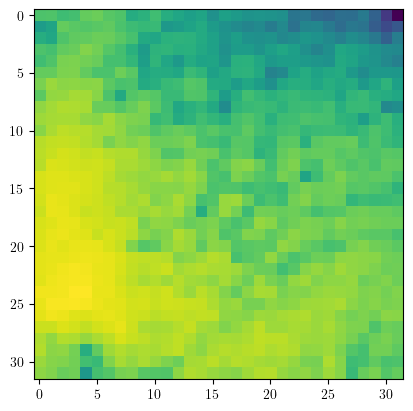

In [15]:
# # dmo_fields.shape
# pl.figure()
# pl.imshow(np.log(np.abs(np.sum(dmo_fields[0,:,:,:,4], axis=0))))
